In [1]:
import os
import pandas as pd
import numpy as np
import cv2
import re

# =============================================================================
# === 【用户配置区域】请在此处修改输入参数 ===
# =============================================================================

# 1. 基础文件夹路径
BASE_DIR = r"C:\Users\81026\Desktop\BallGameWatching"

# 2. 视频与球数据配置
VIDEO_FILENAME = "w14.mp4"       # 视频文件名 (在 GameVideos 下)
TRAJ_FILE_NAME = "tennis.csv"   # 球轨迹文件名 (在 BASE_DIR 下)
TARGET_BALL_VIDEO_ID = "w14"     # 目标视频 ID (对应 tennis.csv 的 video_name)

# 3. 眼动数据配置
EYE_FILE_NAME = "24082301_AD.csv" # 被试文件名 (在 ParticipantsData 下)
TARGET_EYE_TRIAL_ID = "w14"        # 对应 videoName 列的值 (如 "w6" 或 "w6_1_1")

# 4. 【核心修复】坐标系定义与变换参数
# 原始采集设备的分辨率
SRC_SCREEN_W = 1280
SRC_SCREEN_H = 720
# 目标视频的分辨率
TGT_VIDEO_W = 1920
TGT_VIDEO_H = 1080

# Y轴方向修正开关：
# 如果生成的视频中，眼动点上下移动方向是反的（如球往下掉，眼动点往上飘），请将此改为 True
# 如果方向一致，保持 False
FLIP_Y_AXIS = True

# 5. 输出文件
OUTPUT_FILENAME = "visualized_fixed_center.mp4"
SHOW_PREVIEW = False # 是否弹窗预览

# =============================================================================
# === 核心处理逻辑 ===
# =============================================================================

# 路径拼接
VIDEO_PATH = os.path.join(BASE_DIR, "GameVideos", VIDEO_FILENAME)
TRAJ_PATH = os.path.join(BASE_DIR, TRAJ_FILE_NAME)
EYE_PATH = os.path.join(BASE_DIR, "ParticipantsData", EYE_FILE_NAME)
OUTPUT_PATH = os.path.join(BASE_DIR, OUTPUT_FILENAME)

# 绘图样式
COLOR_BALL = (0, 165, 255) # 橙色 (BGR)
COLOR_EYE = (255, 0, 0)    # 蓝色
RADIUS_BALL = 10
RADIUS_EYE = 15
TRAIL_LENGTH = 20          # 轨迹长度

def transform_coordinates(x_raw, y_raw):
    """
    【核心修复函数】
    将 "以屏幕中心为原点 (1280x720)" 的坐标
    转换为 "以左上角为原点 (1920x1080)" 的坐标
    """
    # 1. 平移原点 (Center -> TopLeft)
    # 原始中心(0,0) 应该变成 (640, 360)
    x_pixel = x_raw + (SRC_SCREEN_W / 2.0)

    # Y轴处理
    if FLIP_Y_AXIS:
        # 如果原始数据是数学坐标系(向上为正)，需要翻转为图像坐标系(向下为正)
        # y_pixel = 360 - y_raw
        y_pixel = (SRC_SCREEN_H / 2.0) - y_raw
    else:
        # 如果原始数据已经是向下为正
        y_pixel = y_raw + (SRC_SCREEN_H / 2.0)

    # 2. 缩放 (1280p -> 1080p)
    scale_x = TGT_VIDEO_W / SRC_SCREEN_W  # 1.5
    scale_y = TGT_VIDEO_H / SRC_SCREEN_H  # 1.5

    x_final = x_pixel * scale_x
    y_final = y_pixel * scale_y

    return x_final, y_final

def fit_trajectory_series(df, index_col, value_cols):
    """数据插值与平滑"""
    if df.empty: return df

    df_fit = df.copy().set_index(index_col).sort_index()

    # 针对帧号进行重新索引，填补空缺帧
    if pd.api.types.is_integer_dtype(df_fit.index):
        full_idx = range(int(df_fit.index.min()), int(df_fit.index.max()) + 1)
        df_fit = df_fit.reindex(full_idx)

    for col in value_cols:
        df_fit[col] = df_fit[col].interpolate(method='linear', limit_direction='both')
        # 轻微平滑
        df_fit[f'{col}_smooth'] = df_fit[col].rolling(window=3, center=True, min_periods=1).mean()

    return df_fit.reset_index()

def load_ball_data():
    """读取并解析球轨迹 (假设球数据已经是对应的像素坐标)"""
    print(f"正在读取球轨迹: {TRAJ_FILE_NAME} (ID: {TARGET_BALL_VIDEO_ID})")
    if not os.path.exists(TRAJ_PATH):
        print(f"错误: 找不到文件 {TRAJ_PATH}")
        return pd.DataFrame()

    try:
        df_all = pd.read_csv(TRAJ_PATH)
        df_target = df_all[df_all['video_name'] == TARGET_BALL_VIDEO_ID].copy()

        if df_target.empty:
            print(f"警告: 未找到球轨迹数据。")
            return pd.DataFrame()

        # 解析 "(x, y)"
        df_target["position"] = df_target["position"].astype(str).str.replace(" ", "")
        df_target["Ball.x"] = df_target["position"].apply(lambda x: float(x.split(",")[0][1:]))
        df_target["Ball.y"] = df_target["position"].apply(lambda x: float(x.split(",")[1][:-1]))

        df_clean = df_target[['frame_number', 'Ball.x', 'Ball.y']].rename(columns={'frame_number': 'frame'})
        return fit_trajectory_series(df_clean, 'frame', ['Ball.x', 'Ball.y'])

    except Exception as e:
        print(f"球数据解析出错: {e}")
        return pd.DataFrame()

def load_eye_data():
    """读取眼动数据并应用坐标变换"""
    print(f"正在读取眼动数据: {EYE_FILE_NAME} (ID: {TARGET_EYE_TRIAL_ID})")
    if not os.path.exists(EYE_PATH):
        print("提示: 眼动文件不存在，跳过。")
        return pd.DataFrame()

    try:
        df_raw = pd.read_csv(EYE_PATH)
        df_raw.columns = [c.strip() for c in df_raw.columns] # 清理列名空格

        target_row = df_raw[df_raw['videoName'] == TARGET_EYE_TRIAL_ID]
        if target_row.empty:
            print(f"警告: 未找到 videoName='{TARGET_EYE_TRIAL_ID}' 的行。")
            return pd.DataFrame()

        raw_str = target_row.iloc[0]["EyeData"]
        print(f"-> 找到数据，正在解析并进行坐标变换...")

        data_list = []

        # 解析逻辑 (支持 ; 分隔 或 正则匹配)
        if ";" in raw_str:
            rows = raw_str.split(";")
            for i, row in enumerate(rows[1:], 1):
                vals = row.split(" ")
                try:
                    if vals[0] != "NaN":
                        rx, ry = float(vals[0]), float(vals[1])
                        # === 应用坐标变换 ===
                        tx, ty = transform_coordinates(rx, ry)
                        data_list.append({'sample_index': i, 'Eye.x': tx, 'Eye.y': ty})
                    else:
                        data_list.append({'sample_index': i, 'Eye.x': np.nan, 'Eye.y': np.nan})
                except:
                    pass
        else:
            pattern = r"\((-?\d+(?:\.\d+)?|NaN), (-?\d+(?:\.\d+)?|NaN)\)"
            matches = re.findall(pattern, raw_str)
            for i, (x_str, y_str) in enumerate(matches, 1):
                if x_str != "NaN" and y_str != "NaN":
                    rx, ry = float(x_str), float(y_str)
                    # === 应用坐标变换 ===
                    tx, ty = transform_coordinates(rx, ry)
                    data_list.append({'sample_index': i, 'Eye.x': tx, 'Eye.y': ty})
                else:
                    data_list.append({'sample_index': i, 'Eye.x': np.nan, 'Eye.y': np.nan})

        df = pd.DataFrame(data_list)
        return fit_trajectory_series(df, 'sample_index', ['Eye.x', 'Eye.y'])

    except Exception as e:
        print(f"眼动数据解析失败: {e}")
        return pd.DataFrame()

def main():
    # 1. 准备数据
    df_ball = load_ball_data()
    df_eye = load_eye_data()

    # 2. 视频初始化
    if not os.path.exists(VIDEO_PATH):
        print(f"错误: 找不到视频文件 {VIDEO_PATH}")
        return

    cap = cv2.VideoCapture(VIDEO_PATH)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"\n视频加载: {width}x{height}, FPS={fps:.2f}, Frames={total_frames}")

    # 输出初始化
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height))

    ball_trail = []
    eye_trail = []
    frame_idx = 0

    print(f"开始处理... 输出至: {OUTPUT_FILENAME}")

    while True:
        ret, frame = cap.read()
        if not ret: break

        curr_frame_num = frame_idx + 1

        # --- A. 绘制球 ---
        if not df_ball.empty:
            curr_ball = df_ball[df_ball['frame'] == curr_frame_num]
            if not curr_ball.empty:
                bx, by = curr_ball.iloc[0]['Ball.x_smooth'], curr_ball.iloc[0]['Ball.y_smooth']
                if not np.isnan(bx) and not np.isnan(by):
                    ball_trail.append((int(bx), int(by)))

            if len(ball_trail) > TRAIL_LENGTH: ball_trail.pop(0)

            # 画轨迹
            for i in range(1, len(ball_trail)):
                thick = int(2 + 3 * (i/len(ball_trail)))
                cv2.line(frame, ball_trail[i-1], ball_trail[i], COLOR_BALL, thick)
            # 画点
            if ball_trail:
                cv2.circle(frame, ball_trail[-1], RADIUS_BALL, COLOR_BALL, -1)

        # --- B. 绘制眼动 ---
        if not df_eye.empty:
            # 时间同步: 简单的线性映射 (Video Progress -> Eye Progress)
            eye_idx = int((frame_idx / total_frames) * len(df_eye))

            if eye_idx < len(df_eye):
                ex, ey = df_eye.iloc[eye_idx]['Eye.x_smooth'], df_eye.iloc[eye_idx]['Eye.y_smooth']
                if not np.isnan(ex) and not np.isnan(ey):
                    # 边界检查，防止画到屏幕外
                    ex = max(0, min(width, ex))
                    ey = max(0, min(height, ey))
                    eye_trail.append((int(ex), int(ey)))

            if len(eye_trail) > TRAIL_LENGTH: eye_trail.pop(0)

            # 半透明绘制
            overlay = frame.copy()
            if len(eye_trail) > 1:
                # 绘制多边形线段
                pts = np.array(eye_trail, np.int32).reshape((-1, 1, 2))
                cv2.polylines(overlay, [pts], False, COLOR_EYE, 2)
            if eye_trail:
                cv2.circle(overlay, eye_trail[-1], RADIUS_EYE, COLOR_EYE, -1)

            cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)

        # --- 文字 ---
        cv2.putText(frame, f"Frame: {curr_frame_num}", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)

        out.write(frame)

        if SHOW_PREVIEW:
            cv2.imshow('Preview', cv2.resize(frame, (960, 540)))
            if cv2.waitKey(1) & 0xFF == ord('q'): break

        frame_idx += 1
        if frame_idx % 50 == 0: print(f"进度: {frame_idx}/{total_frames}...")

    cap.release()
    out.release()
    cv2.destroyAllWindows()
    print("完成！")

if __name__ == "__main__":
    main()


正在读取球轨迹: tennis.csv (ID: w14)
正在读取眼动数据: 24082301_AD.csv (ID: w14)
-> 找到数据，正在解析并进行坐标变换...

视频加载: 1924x1080, FPS=30.00, Frames=845
开始处理... 输出至: visualized_fixed_center.mp4
进度: 50/845...
进度: 100/845...
进度: 150/845...
进度: 200/845...
进度: 250/845...
进度: 300/845...
进度: 350/845...
进度: 400/845...
进度: 450/845...
进度: 500/845...
进度: 550/845...
进度: 600/845...
进度: 650/845...
进度: 700/845...
进度: 750/845...
进度: 800/845...
完成！


Loading Ball Data: w14...
Loading Eye Data: w14...


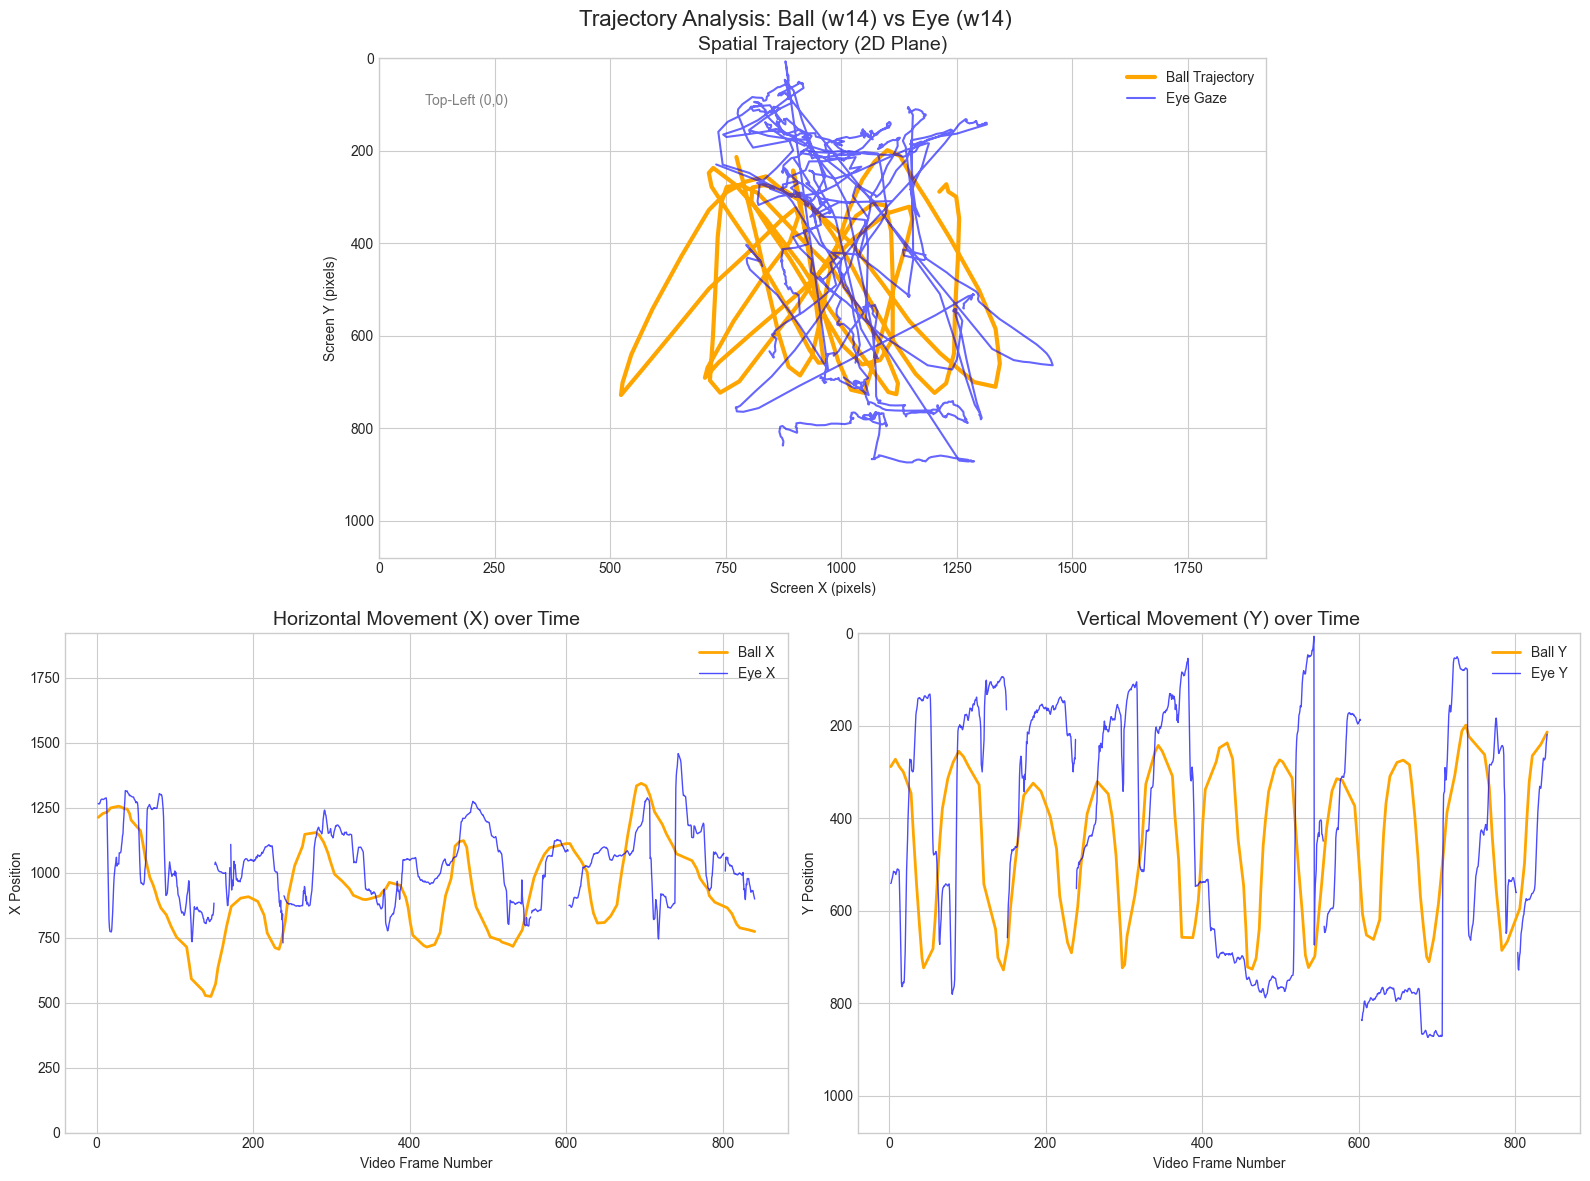


=== 数据统计 ===
Ball Data: Frames 2 to 841 (Total 146 points)
Eye Data:  Mapped to frames (Total 1408 samples)
可视化生成完毕。


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =============================================================================
# === 【用户配置区域】 ===
# =============================================================================

# 1. 基础文件夹路径
BASE_DIR = r"C:\Users\81026\Desktop\BallGameWatching"

# 2. 球轨迹配置 (tennis.csv)
TRAJ_FILE_NAME = "tennis.csv"
TARGET_BALL_VIDEO_ID = "w14"   # 目标视频 ID

# 3. 眼动数据配置 (ParticipantsData)
EYE_FILE_NAME = "24082301_AD.csv"
TARGET_EYE_TRIAL_ID = "w14"    # 对应 videoName 列

# 4. 坐标系与分辨率配置
# 源设备 (眼动仪)
SRC_SCREEN_W = 1280
SRC_SCREEN_H = 720
# 目标空间 (视频)
TGT_VIDEO_W = 1920
TGT_VIDEO_H = 1080

# Y轴翻转开关:
# 如果眼动仪数据是 "向上为正" (数学坐标系)，设为 True 以转换为 "向下为正" (图像坐标系)
FLIP_Y_AXIS = True

# =============================================================================
# === 数据处理逻辑 ===
# =============================================================================

TRAJ_PATH = os.path.join(BASE_DIR, TRAJ_FILE_NAME)
EYE_PATH = os.path.join(BASE_DIR, "ParticipantsData", EYE_FILE_NAME)

def transform_coordinates(x_raw, y_raw):
    """
    将 [以屏幕中心为原点, 1280x720] 的坐标
    转换为 [以左上角为原点, 1920x1080] 的坐标
    """
    # 1. 平移原点 (Center -> TopLeft)
    # 原始中心(0,0) -> 对应像素 (640, 360)
    x_pixel = x_raw + (SRC_SCREEN_W / 2.0)

    # Y轴处理
    if FLIP_Y_AXIS:
        # 翻转: (720/2) - y_raw
        y_pixel = (SRC_SCREEN_H / 2.0) - y_raw
    else:
        # 不翻转: (720/2) + y_raw
        y_pixel = y_raw + (SRC_SCREEN_H / 2.0)

    # 2. 缩放 (1280 -> 1920)
    scale_x = TGT_VIDEO_W / SRC_SCREEN_W
    scale_y = TGT_VIDEO_H / SRC_SCREEN_H

    x_final = x_pixel * scale_x
    y_final = y_pixel * scale_y

    return x_final, y_final

def smooth_data(series, window=5):
    """简单的数据平滑，去除抖动"""
    return series.rolling(window=window, center=True, min_periods=1).mean()

def load_ball_data():
    print(f"Loading Ball Data: {TARGET_BALL_VIDEO_ID}...")
    if not os.path.exists(TRAJ_PATH): return pd.DataFrame()

    try:
        df = pd.read_csv(TRAJ_PATH)
        df = df[df['video_name'] == TARGET_BALL_VIDEO_ID].copy()
        if df.empty: return pd.DataFrame()

        # 解析坐标
        df["position"] = df["position"].astype(str).str.replace(" ", "")
        df["x"] = df["position"].apply(lambda x: float(x.split(",")[0][1:]))
        df["y"] = df["position"].apply(lambda x: float(x.split(",")[1][:-1]))

        # 排序并平滑
        df = df.sort_values("frame_number")
        df["x_smooth"] = smooth_data(df["x"])
        df["y_smooth"] = smooth_data(df["y"])

        return df
    except Exception as e:
        print(f"Error loading ball data: {e}")
        return pd.DataFrame()

def load_eye_data():
    print(f"Loading Eye Data: {TARGET_EYE_TRIAL_ID}...")
    if not os.path.exists(EYE_PATH): return pd.DataFrame()

    try:
        df_raw = pd.read_csv(EYE_PATH)
        df_raw.columns = [c.strip() for c in df_raw.columns]
        target_row = df_raw[df_raw['videoName'] == TARGET_EYE_TRIAL_ID]

        if target_row.empty:
            print("Eye data trial not found.")
            return pd.DataFrame()

        raw_str = target_row.iloc[0]["EyeData"]
        data_points = []

        # 解析数据字符串
        if ";" in raw_str:
            rows = raw_str.split(";")
            for i, row in enumerate(rows[1:], 1):
                vals = row.split(" ")
                try:
                    if vals[0] != "NaN":
                        tx, ty = transform_coordinates(float(vals[0]), float(vals[1]))
                        data_points.append({'idx': i, 'x': tx, 'y': ty})
                    else:
                        data_points.append({'idx': i, 'x': np.nan, 'y': np.nan})
                except: pass
        else:
            pattern = r"\((-?\d+(?:\.\d+)?|NaN), (-?\d+(?:\.\d+)?|NaN)\)"
            matches = re.findall(pattern, raw_str)
            for i, (x_str, y_str) in enumerate(matches, 1):
                if x_str != "NaN":
                    tx, ty = transform_coordinates(float(x_str), float(y_str))
                    data_points.append({'idx': i, 'x': tx, 'y': ty})
                else:
                    data_points.append({'idx': i, 'x': np.nan, 'y': np.nan})

        df = pd.DataFrame(data_points)
        if not df.empty:
            df["x_smooth"] = smooth_data(df["x"])
            df["y_smooth"] = smooth_data(df["y"])
        return df
    except Exception as e:
        print(f"Error loading eye data: {e}")
        return pd.DataFrame()

# =============================================================================
# === 可视化主程序 ===
# =============================================================================

def main():
    # 1. 加载数据
    df_ball = load_ball_data()
    df_eye = load_eye_data()

    if df_ball.empty or df_eye.empty:
        print("错误：无法加载完整数据，请检查配置或文件内容。")
        return

    # 2. 对齐时间轴 (Frame Alignment)
    # 球数据已经有 frame_number
    # 眼动数据需要映射到 frame_number
    min_frame = df_ball['frame_number'].min()
    max_frame = df_ball['frame_number'].max()
    total_video_frames = max_frame - min_frame + 1

    # 假设眼动数据均匀分布在视频播放期间
    # 创建一个虚拟帧号列 (Virtual Frame) 用于绘图对齐
    eye_samples = len(df_eye)
    df_eye['virtual_frame'] = np.linspace(min_frame, max_frame, eye_samples)

    # 3. 开始绘图
    plt.style.use('seaborn-v0_8-whitegrid')
    fig = plt.figure(figsize=(16, 12))
    fig.suptitle(f"Trajectory Analysis: Ball ({TARGET_BALL_VIDEO_ID}) vs Eye ({TARGET_EYE_TRIAL_ID})", fontsize=16)

    # --- 子图 1: 空间平面图 (X vs Y) ---
    ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
    ax1.set_title("Spatial Trajectory (2D Plane)", fontsize=14)
    ax1.plot(df_ball['x_smooth'], df_ball['y_smooth'], color='orange', linewidth=3, label='Ball Trajectory')
    ax1.plot(df_eye['x_smooth'], df_eye['y_smooth'], color='blue', alpha=0.6, linewidth=1.5, label='Eye Gaze')

    # 设置坐标轴范围与背景 (模拟 1920x1080 屏幕)
    ax1.set_xlim(0, TGT_VIDEO_W)
    ax1.set_ylim(TGT_VIDEO_H, 0) # 翻转Y轴，让0在左上角，符合屏幕直觉
    ax1.set_aspect('equal')
    ax1.set_xlabel("Screen X (pixels)")
    ax1.set_ylabel("Screen Y (pixels)")
    ax1.legend(loc='upper right')
    ax1.text(100, 100, "Top-Left (0,0)", color='gray')

    # --- 子图 2: X轴时序对比 (X vs Time) ---
    ax2 = plt.subplot2grid((2, 2), (1, 0))
    ax2.set_title("Horizontal Movement (X) over Time", fontsize=14)
    ax2.plot(df_ball['frame_number'], df_ball['x_smooth'], color='orange', linewidth=2, label='Ball X')
    ax2.plot(df_eye['virtual_frame'], df_eye['x_smooth'], color='blue', alpha=0.7, linewidth=1, label='Eye X')

    ax2.set_xlabel("Video Frame Number")
    ax2.set_ylabel("X Position")
    ax2.set_ylim(0, TGT_VIDEO_W)
    ax2.legend()

    # --- 子图 3: Y轴时序对比 (Y vs Time) ---
    ax3 = plt.subplot2grid((2, 2), (1, 1))
    ax3.set_title("Vertical Movement (Y) over Time", fontsize=14)
    ax3.plot(df_ball['frame_number'], df_ball['y_smooth'], color='orange', linewidth=2, label='Ball Y')
    ax3.plot(df_eye['virtual_frame'], df_eye['y_smooth'], color='blue', alpha=0.7, linewidth=1, label='Eye Y')

    ax3.set_xlabel("Video Frame Number")
    ax3.set_ylabel("Y Position")
    ax3.set_ylim(TGT_VIDEO_H, 0) # Y轴倒置，符合屏幕直觉
    ax3.legend()

    plt.tight_layout()
    plt.show()

    # --- 打印对齐信息 ---
    print("\n=== 数据统计 ===")
    print(f"Ball Data: Frames {min_frame} to {max_frame} (Total {len(df_ball)} points)")
    print(f"Eye Data:  Mapped to frames (Total {len(df_eye)} samples)")
    print("可视化生成完毕。")

if __name__ == "__main__":
    main()
